# **03. Exploring Property Type in Ames, Iowa**

# **Motivation**

The motivation for this report is to turn a rich housing dataset into practical insights about how property characteristics and market dynamics have evolved in Ames, Iowa. By examining historical trends, building types, and price drivers, the analysis aims to:

- reveal how home features such as size, age, and layout changed over time,
- compare single-household property types (single-family homes, townhouses) with multi-household or shared-living types (duplexes, two-family conversions),
- identify the most influential features that determine sale price.

These findings can help home buyers, sellers, investors, and planners understand which property attributes are most important in the local market, and how changing housing patterns influence value.

## **Goal**

__1. How have houses changed in their features over the years?__

__2. How have market dynamics shifted between properties designed for single households, such as single‑family homes and townhouses, and those designed for multiple households or shared living, such as duplexes and two‑family conversions, over time?__

__3. Which features make houses sell best?__

## **Introduction**

The housing market affects everyone, from big real estate investors to families looking for a home. It's a complicated system, with prices and trends shifting constantly over time. In this report, we aim to make sense of these changes and provide a clearer picture of how the market has evolved. To do this, we'll analyze data from 1,460 property sales recorded between 2006 and 2010. Within this dataset, our focus will be on....


The data was collected by De Cock and recorded 1460 properties in Ames, IA.

Brief description of columns:

- **Id:** Property ID (unique identifier)
- **LotArea:** Lot size (sq ft)
- **BldgType:** Building type (Single-family, Duplex)
- **YearBuilt:** Year of construction
- **GrLivArea:** Above-ground living area
- **BsmtFullBath/BsmtHalfBath:** Basement bathrooms
- **FullBath/HalfBath:** Bathrooms above ground
- **BedroomAbvGr:** Bedrooms above ground
- **TotRmsAbvGrd:** Total rooms above ground
- **SalePrice:** Target variable — final selling price


**This dataset represents the sale of properties in Ames, Iowa, where every single record represents a sale of individual house.
There are identification, land lot information, house characteristics, exterior, sales information and other features describing each house. The data of selling houses spans from 2006 to 2010.**

### __Import Libraries__

In [1]:
import sys
sys.path.append("..")
from src.utilis import *

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm
import statsmodels.formula.api as smf


### **Basic Understanding & Data Ingestion**

In [2]:
# define path
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

org_files = []
display_md("**Original Files :**")
for file in data_path.rglob("*.csv"):
    org_files.append(file)
    print(org_files.index(file), " ", file.name)

pro_files = []
display_md("**Cleaned Files :**")
for fle in processed_path.rglob("*"):
    pro_files.append(fle)
    print(pro_files.index(fle), " ", fle.name)


**Original Files :**

0   sample_submission.csv
1   test.csv
2   train.csv


**Cleaned Files :**

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [3]:
display_md("**Loading Original Datasets :**")

# Load original data 
train_org = load_data(org_files[2])
test_org = load_data(org_files[1])    

# standardize the column names
train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

display_md("**Original Training and Testing data Shape**")

print("Original Training data shape: ", train_org.shape)
print("Original Testing data shape: ", test_org.shape)

display_md("**Duplicate Rows in  Data**")

print("Number of duplicate rows in training data: ", train_org.duplicated().sum())
print("Number of duplicate rows in testing data ", test_org.duplicated().sum())


**Loading Original Datasets :**

Data loaded successfully!
Data loaded successfully!


**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in  Data**

Number of duplicate rows in training data:  0
Number of duplicate rows in testing data  0


In [4]:
# Selecting columns for analysis in this notebook and define new train and test datasets
cols = ['Id', 'LotArea', 'BldgType', 'YearBuilt', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'SalePrice']

new_cols = [x for x in cols if x != 'SalePrice']

df_train = train_org[cols].copy()
df_test = test_org[new_cols].copy()


### **Columns Formatting and Consistency**

In [5]:
dtype_df = datatype_df(df_train)
display(dtype_df)


,Dtype,nunique,unique,missing_value
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,...",0
BldgType,object,5,"[1Fam, 2fmCon, Duplex, TwnhsE, Twnhs]",0
YearBuilt,int64,112,"[2003, 1976, 2001, 1915, 2000, 1993, 2004, 197...",0
GrLivArea,int64,861,"[1710, 1262, 1786, 1717, 2198, 1362, 1694, 209...",0
BsmtFullBath,int64,4,"[1, 0, 2, 3]",0
BsmtHalfBath,int64,3,"[0, 1, 2]",0
FullBath,int64,4,"[2, 1, 3, 0]",0
HalfBath,int64,3,"[1, 0, 2]",0
BedroomAbvGr,int64,8,"[3, 4, 1, 2, 0, 5, 6, 8]",0


## **Exploring the Data Through Charts**

Let's use charts and visualizations to explore the key questions identified in the goal section.


#### **`Question 1.` How have houses changed in their features over the years?**

**1.1. Numerical Features Over the Years**


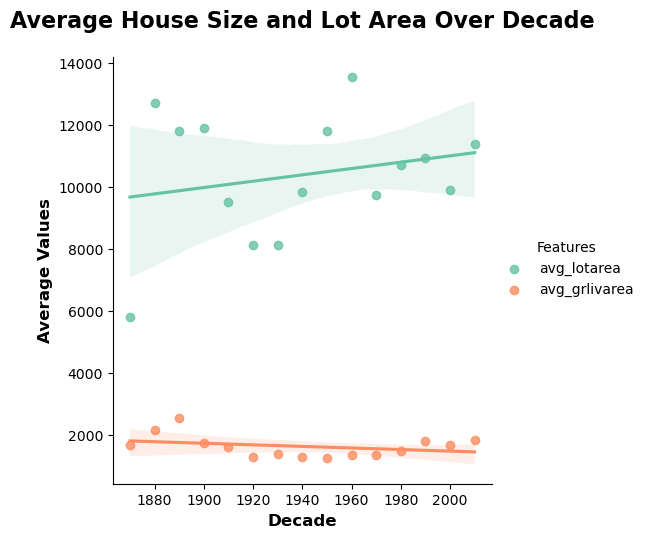

This time‑series plot places decades on the x‑axis and average values (in dollars) on the y‑axis, with each feature distinguished by a separate color for clarity. The visualization tracks how average lot area and above‑ground living area evolve over time. Lot area has generally expanded, while living space has gradually contracted. Among the two, **lot area remains the dominant feature, showing the most substantial increase compared to above‑ground living area.**

In [6]:
# Create a new column for decade bins
df_train["DecadeBuilt"] = (df_train['YearBuilt']//10)*10

num_cols = ['GrLivArea', 'LotArea']
discrete_cols = ['BedroomAbvGr', 'TotRmsAbvGrd', 'FullBath', 'HalfBath']

avg_features = (
    df_train.groupby(['DecadeBuilt'])[num_cols].mean()
    )
avg_features.columns = ["avg_"+col.lower() for col in avg_features.columns]
df_features = avg_features.reset_index()

# Reshape the long format
df_vars = df_features.melt(
    id_vars="DecadeBuilt",
    value_vars=['avg_lotarea','avg_grlivarea'],
    var_name="Features", value_name="average_values"
)
df_vars.head()

# visualize average values of house size and lot are over decade using lmplot
sns.lmplot(
    data=df_vars, 
    x="DecadeBuilt", y="average_values",
    hue="Features", palette=sns.color_palette("Set2", 2)
)
plt.title("Average House Size and Lot Area Over Decade", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Decade", fontsize=12, fontweight='bold')
plt.ylabel("Average Values", fontsize=12, fontweight='bold')

plt.show()

display_md("This time‑series plot places decades on the x‑axis and average values (in dollars) on the y‑axis, with each feature distinguished by a separate color for clarity. The visualization tracks how average lot area and above‑ground living area evolve over time. Lot area has generally expanded, while living space has gradually contracted. Among the two, **lot area remains the dominant feature, showing the most substantial increase compared to above‑ground living area.**")



For a deeper investigation, we conducted a regression analysis using variables such as DecadeBuilt, LotArea, and GrLivArea to examine their influence on house sale prices. The resulting linear model is presented below.


In [7]:
model = smf.ols("SalePrice ~ DecadeBuilt + LotArea  + GrLivArea", data=df_train).fit()
print(model.summary())

display_md("All predictors in the model are statistically significant, with very low p‑values. The R² value of 0.66 indicates that the model explains a fair portion of the variation in sale prices. When DecadeBuilt is excluded, it becomes clear that living area exerts a stronger influence on sale price than lot area. Including DecadeBuilt adds the age effect, showing that newer homes tend to be sold on higher prices. Overall, the regression provides a reasonably accurate estimate of house values.")


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     941.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:23:23   Log-Likelihood:                -17757.
No. Observations:                1460   AIC:                         3.552e+04
Df Residuals:                    1456   BIC:                         3.554e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -2.054e+06   8.15e+04    -25.220      

All predictors in the model are statistically significant, with very low p‑values. The R² value of 0.66 indicates that the model explains a fair portion of the variation in sale prices. When DecadeBuilt is excluded, it becomes clear that living area exerts a stronger influence on sale price than lot area. Including DecadeBuilt adds the age effect, showing that newer homes tend to be sold on higher prices. Overall, the regression provides a reasonably accurate estimate of house values.

**1.2. Discrete Features Across Years**

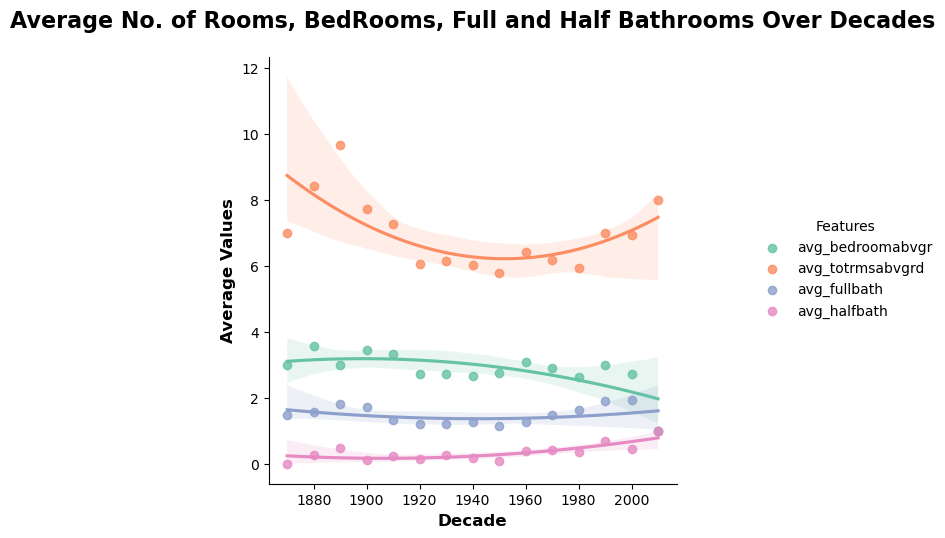

In [8]:
avg_cat = (
    df_train.groupby(['DecadeBuilt'])[discrete_cols].mean()
    )
avg_cat.columns = ["avg_"+col.lower() for col in avg_cat.columns]
df_cat = avg_cat.reset_index()
# Reshape the long format
df_dimensions = df_cat.melt(
    id_vars="DecadeBuilt",
    value_vars=['avg_bedroomabvgr','avg_totrmsabvgrd', 'avg_fullbath', 'avg_halfbath'],
    var_name="Features", value_name="average_values"
)
df_dimensions.head()

# visualize the average number of bed room, rooms, full and half bathroom
sns.lmplot(
    data=df_dimensions, 
    x="DecadeBuilt", y="average_values", order=2,
    hue="Features", palette=sns.color_palette("Set2", 4)
)
plt.title("Average No. of Rooms, BedRooms, Full and Half Bathrooms Over Decades", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Decade", fontsize=12, fontweight='bold')
plt.ylabel("Average Values", fontsize=12, fontweight='bold')

plt.show()


In [9]:
import statsmodels.formula.api as smf
model = smf.ols("SalePrice ~ DecadeBuilt+ BedroomAbvGr+ FullBath+ HalfBath + np.square(HalfBath) + TotRmsAbvGrd", data=df_train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     301.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          4.96e-251
Time:                        02:23:25   Log-Likelihood:                -17954.
No. Observations:                1460   AIC:                         3.592e+04
Df Residuals:                    1453   BIC:                         3.596e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.847e+06   1

The regression on `SalePrice` shows that the structural and age-related features are the main price drivers in this dataset.

- `DecadeBuilt` has a positive effect, so newer-built homes tend to command higher sale prices.
- `BedroomAbvGr`, `FullBath`, and `TotRmsAbvGrd` all contribute positively, meaning more bedrooms, full bathrooms, and total rooms are associated with higher values.
- The `HalfBath` term is modeled nonlinearly, so while adding a half bathroom generally raises price, the squared term suggests diminishing returns from additional half baths after a point.

Overall, the model supports the conclusion that house age and basic size/layout features are strong predictors of sale price, with bathroom mix showing a more nuanced effect.

Next, we take a closer look at Building types using a stacked bar chart. This visualization highlights the count of each property type by the year of construction.

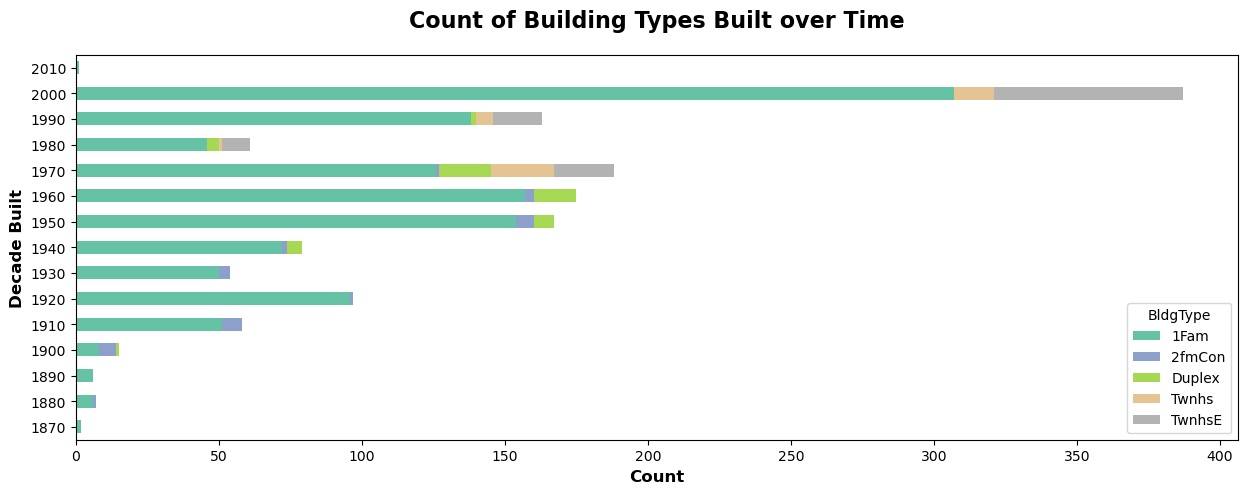

Single‑family homes have been the main type of housing built over time, and its peak during the mid‑20th century. In more recent years, the mix of building types has become more diversified. Townhouses, which were almost nonexistent in earlier decades, have gradually increased as cities grow denser and people look for smaller, easier‑to‑maintain homes. Duplexes have stayed at a low but steady level, while two‑family conversions have declined as newer homes are built to serve those needs directly. Overall, **the data shows a shift from a market dominated by single‑family homes to one with a broader range of housing types.**

In [10]:
df_train.groupby(['DecadeBuilt', 'BldgType']).size().unstack(fill_value=0).plot(kind='barh', colormap="Set2", stacked=True, figsize=(15, 5))
plt.title("Count of Building Types Built over Time",fontsize=16, fontweight='bold', y=1.05)
plt.ylabel("Decade Built", fontsize=12, fontweight='bold')
plt.xlabel("Count",fontsize=12, fontweight='bold')
plt.show()

display_md("Single‑family homes have been the main type of housing built over time, and its peak during the mid‑20th century. In more recent years, the mix of building types has become more diversified. Townhouses, which were almost nonexistent in earlier decades, have gradually increased as cities grow denser and people look for smaller, easier‑to‑maintain homes. Duplexes have stayed at a low but steady level, while two‑family conversions have declined as newer homes are built to serve those needs directly. Overall, **the data shows a shift from a market dominated by single‑family homes to one with a broader range of housing types.**")


---
### **`Question 2.` How have housing market trends changed over time between single-family and multi-family properties?**

Here, single households, are single‑family homes and townhouses & multiple households or shared living, are duplexes and two‑family conversions

To explore these yearly patterns more closely, we plot rolling averages of house size and sale price by year of construction, segmented by building type. The rolling average smooths fluctuations in the time series, offering a clearer view of long‑term trends while reflecting the connected nature of the data — each year's values are influenced by those of the preceding year.


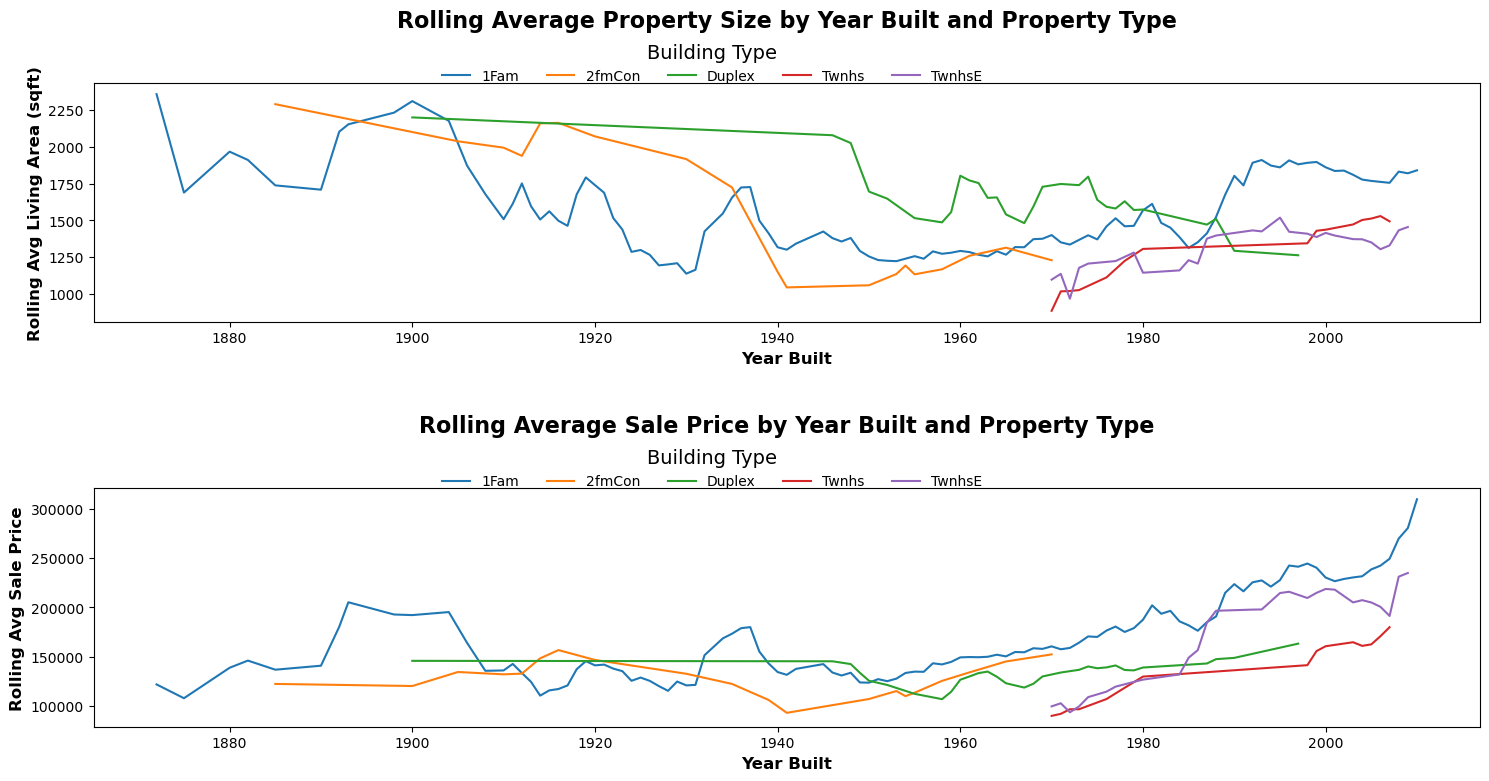

**Building type significantly influences both house size and price, with single-family homes generally larger and more expensive than townhouses or duplexes, and this effect interacts with the year built and market trends.**

In [11]:

# df has columns: YearBuilt, BldgType, GrLivArea (property size), SalePrice

# Sort by YearBuilt to ensure rolling works correctly
df = df_train.sort_values("YearBuilt")

# Aggregate by YearBuilt + BldgType
grouped = df.groupby(["YearBuilt", "BldgType"]).agg({
    "GrLivArea": "mean",
    "SalePrice": "mean"
}).reset_index()

# Sort by YearBuilt
grouped = grouped.sort_values("YearBuilt")

# Apply rolling averages within each building type
grouped["rolling_size"] = grouped.groupby("BldgType")["GrLivArea"].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
grouped["rolling_price"] = grouped.groupby("BldgType")["SalePrice"].transform(lambda x: x.rolling(window=5, min_periods=1).mean())


# plot rolling size and sale price
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
sns.lineplot(data=grouped, x="YearBuilt", y="rolling_size", hue="BldgType", ax=ax[0])
ax[0].set_title("Rolling Average Property Size by Year Built and Property Type", fontsize=16, fontweight='bold', y=1.20)
ax[0].set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax[0].set_ylabel("Rolling Avg Living Area (sqft)", fontsize=12, fontweight='bold')
ax[0].legend(title="Building Type", title_fontsize=14, loc='upper right', bbox_to_anchor=(0.65, 1.22), ncol=6, frameon=False)

# Plot rolling sale price
sns.lineplot(data=grouped, x="YearBuilt", y="rolling_price", hue="BldgType", ax=ax[1])
ax[1].set_title("Rolling Average Sale Price by Year Built and Property Type", fontsize=16, fontweight='bold', y=1.20)
ax[1].set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax[1].set_ylabel("Rolling Avg Sale Price", fontsize=12, fontweight='bold')
ax[1].legend(title="Building Type", title_fontsize=14, loc='upper right', bbox_to_anchor=(0.65, 1.22), ncol=6, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.7)
plt.show()

display_md("**Building type significantly influences both house size and price, with single-family homes generally larger and more expensive than townhouses or duplexes, and this effect interacts with the year built and market trends.**")



Next, we examine the distribution of building types in greater detail, breaking them down by the average number of rooms, bedrooms capacity they provide. 


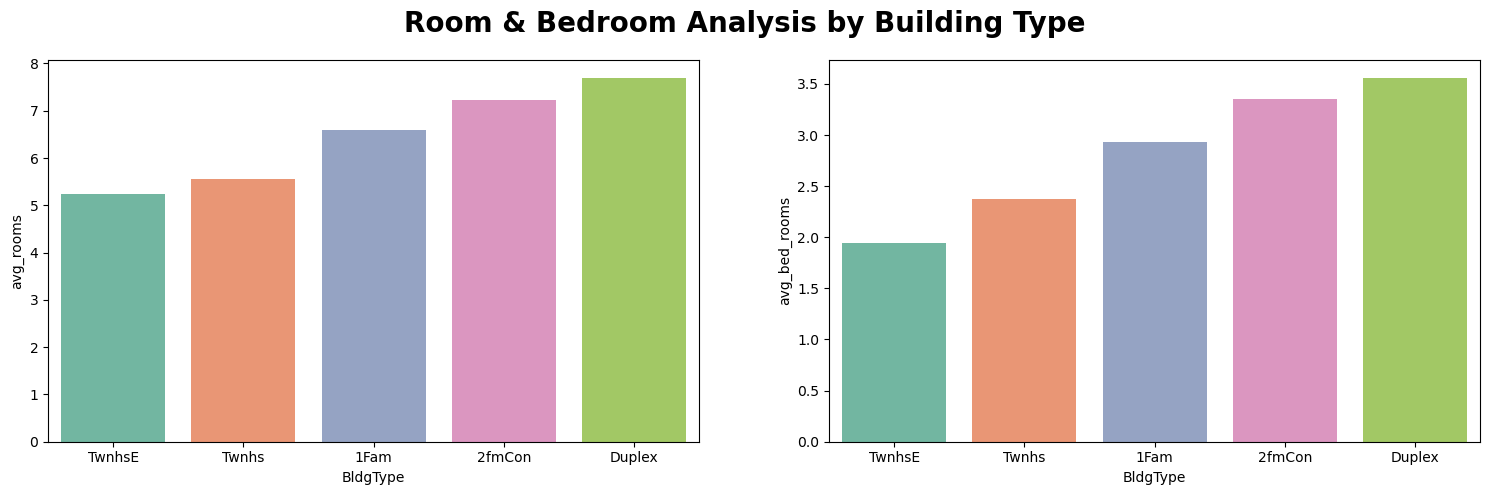

From the plot, we can see that Duplex homes tend to have the highest average room and bed rooms and  counts, followed by Two-family Conversion and single-family. Other building types show lower averages, with several categories clustering closely together in terms of room numbers. This visual format makes it easy to identify which building types generally offer more living space and which provide less, insights that can be valuable for investors, home buyers, urban planners, and developers seeking to understand the characteristics of different housing categories.

In [12]:
df_bldg = df_train.groupby(['BldgType']).agg(
    avg_rooms = ('TotRmsAbvGrd', 'mean'),
    avg_bed_rooms = ('BedroomAbvGr', 'mean')
).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df_bldg.sort_values(by='avg_rooms', ascending=True), 
            x='BldgType', 
            y='avg_rooms',
            ax=ax[0],
            palette='Set2')

sns.barplot(data=df_bldg.sort_values(by='avg_bed_rooms', ascending=True),
            x='BldgType', 
            y='avg_bed_rooms', 
            ax=ax[1],
            palette='Set2')

fig.suptitle("Room & Bedroom Analysis by Building Type", fontsize=20, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

display_md("From the plot, we can see that Duplex homes tend to have the highest average room and bed rooms and  counts, followed by Two-family Conversion and single-family. Other building types show lower averages, with several categories clustering closely together in terms of room numbers. This visual format makes it easy to identify which building types generally offer more living space and which provide less, insights that can be valuable for investors, home buyers, urban planners, and developers seeking to understand the characteristics of different housing categories.")



To examine how building type affects house sale prices over time, we will use a heatmap visualization. The color scale will represent the range of sale prices, from the minimum to the maximum value. This visualization will help highlight variations in sale prices among different building types across different years.

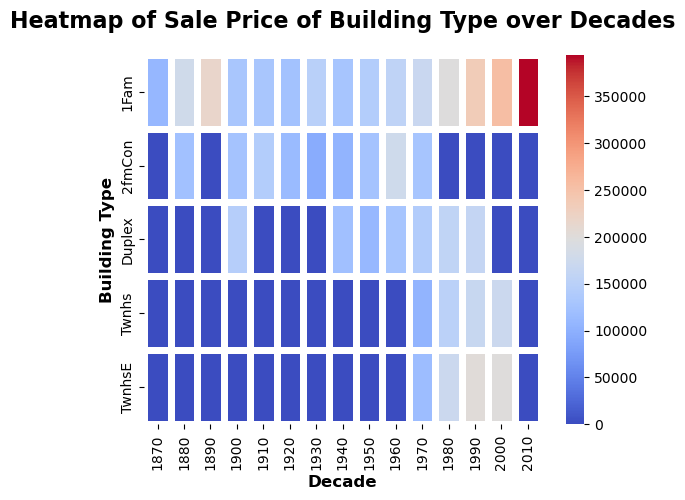

This heatmap illustrates how average house sale prices vary by decade and building type. Red highlights the highest‑valued properties, while blue marks the lowest. To keep the visualization clear, only major building types were included, and years were grouped into decades. Sale price is strongly shaped by building type: **single‑family homes are consistently more expensive, especially in newer construction years. Townhouses and duplexes remain more affordable, though their relative value shifts depending on construction era. Notably, end‑unit townhouses show a trend toward higher prices after 1980, which may reflect increased demand or improvements in construction quality — a pattern worth exploring further.**

In [13]:
house_df= df_train.pivot_table(
    index='BldgType', 
    columns='DecadeBuilt',
    values='SalePrice',
    aggfunc='mean').fillna(0)

sns.heatmap(house_df, cmap='coolwarm', lw=5)
plt.title("Heatmap of Sale Price of Building Type over Decades", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Decade", fontsize=12, fontweight='bold')
plt.ylabel("Building Type", fontsize=12, fontweight='bold')
plt.show()

display_md("This heatmap illustrates how average house sale prices vary by decade and building type. Red highlights the highest‑valued properties, while blue marks the lowest. To keep the visualization clear, only major building types were included, and years were grouped into decades. Sale price is strongly shaped by building type: **single‑family homes are consistently more expensive, especially in newer construction years. Townhouses and duplexes remain more affordable, though their relative value shifts depending on construction era. Notably, end‑unit townhouses show a trend toward higher prices after 1980, which may reflect increased demand or improvements in construction quality — a pattern worth exploring further.**")



---
### **`Question 3.` Which features make houses sell best?**

To identify the features that drive house sales most effectively, I will focus on the variables already examined in our exploratory data analysis file, ensuring a clear and consistent understanding. For this, will run linear regression on the features.


In [14]:
# Select features
cols = ['DecadeBuilt', 'LotArea', 'GrLivArea', 'BldgType']
X = df_train[cols]

# Convert categorical to dummies
X_dummy = pd.get_dummies(X, drop_first=True)
X_dummy = X_dummy.astype(int)


# Target
y = df_train['SalePrice']
y_log = np.log(y)+1

# Add constant
X_dummy = sm.add_constant(X_dummy)

# Fit model
model = sm.OLS(y_log, X_dummy).fit()

print(model.summary())

display_md("Linear model suggests that **single‑family homes dominate** in price, serving as the baseline category.**Duplexes and interior townhouses** are substantially less expensive, even after controlling for decade, lot size, and living area. **End‑unit townhouses** show no significant discount compared to single‑family homes, hinting at stronger demand or better construction quality. **Structural features (lot size, living area, decade)** remain the primary drivers of price, but building type introduces meaningful differences.")

display_md("**Key Finding : Heatmap and linear model results tells the same story. Newer, larger living-area & lots sell for more, and building type matters — duplexes and interior townhouses are discounted relative to single‑family homes, while end‑unit townhouses hold their value much better.**")



                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     552.1
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:23:30   Log-Likelihood:                 216.14
No. Observations:                1460   AIC:                            -416.3
Df Residuals:                    1452   BIC:                            -374.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0257      0.392     

Linear model suggests that **single‑family homes dominate** in price, serving as the baseline category.**Duplexes and interior townhouses** are substantially less expensive, even after controlling for decade, lot size, and living area. **End‑unit townhouses** show no significant discount compared to single‑family homes, hinting at stronger demand or better construction quality. **Structural features (lot size, living area, decade)** remain the primary drivers of price, but building type introduces meaningful differences.

**Key Finding : Heatmap and linear model results tells the same story. Newer, larger living-area & lots sell for more, and building type matters — duplexes and interior townhouses are discounted relative to single‑family homes, while end‑unit townhouses hold their value much better.**

---
## **Conclusion**

- Changes over time
    - Average lot area grew across decades, while above-ground living area showed a more modest trend and in some cases flattened or contracted.
    - The average number of bedrooms, rooms, and bathrooms changed less dramatically, but the data suggests newer construction tended to emphasize more efficient layouts rather than much larger footprints.

- Building type dynamics
    - Single-family homes remain the dominant building type historically and typically command the highest average prices.
    - Townhouses and duplexes occupy a smaller share; duplexes and two-family conversions tend to be lower-priced, while end-unit townhouses have higher relative value and appear to be closer to single-family pricing.
    - Rolling averages by year built show that building type strongly interacts with market value: single-family properties are generally larger and more expensive than other categories, while townhouses and duplexes remain more affordable.

- Price drivers
    - Regression analysis with `SalePrice ~ DecadeBuilt + LotArea + GrLivArea` found all predictors significant and produced an R^2 around 0.66, indicating this simple model captures a meaningful portion of sale price variation.
    - A log-price regression including building-type dummy variables confirmed that year built, lot size, and living area are the main price drivers.
    - Building type also matters: duplexes and interior townhouses are priced below the single-family baseline, while end-unit townhouses show much smaller discounts.

- Practical takeaway
    - Newer, larger homes on bigger lots sell for more.
    - Building type remains an important secondary factor: single-family homes are premium, while multi-unit and interior townhouse forms carry discounts.
    - End-unit townhouses are the strongest exception among non-single-family types, suggesting they are more competitive with single-family values.

Overall, the analysis supports a clear story: structural size and age explain much of the price variation, but market segmentation by building type is also essential for understanding house values in Ames.

In [15]:
print("="*65 + " COMPLETED " + "="*65)

================================================================= COMPLETED =================================================================
